# Phase 2 — Exploratory Data Analysis (EDA)
## Project: Machine Learning-based Ransomware Detection Using Low-level Memory Access Patterns
### Dataset: RanSMAP 2024 | Reference: Hirano & Kobayashi, IEEE CSR 2022

**Goal:** Understand the raw memory access data before building ML models.
Explore patterns, clean the data, and find what makes ransomware different from benign applications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import os

# paths
PROCESSED = r"C:\Users\Shiva\Downloads\RANSMAP_PROJECT\DATA\processed"

# plot style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 120
sns.set_theme(style="whitegrid")

print("Libraries loaded!")
print(f"Processed folder exists: {os.path.exists(PROCESSED)}")

Libraries loaded!
Processed folder exists: True


## 1. Understanding the Dataset

We are working with `mem_write_combined.parquet` — memory write events captured by a hypervisor.

Each row = one memory page write event with:
- `class_name` — which program was running (WannaCry, Idle, AESCrypt etc.)
- `label` — malicious or benign
- `is_malicious` — 1 = malicious, 0 = benign
- `entropy` — randomness of written data (0 = zeros, 1 = fully random/encrypted)
- `page_type` — type of memory page accessed
- `trial_id` — which specific trial run
- `split` — which dataset split (original, extra, mix, variants)

In [ ]:
# Load a sample from mem_write parquet — row by row to avoid RAM crash
path = os.path.join(PROCESSED, "mem_write_combined.parquet")
cols = ["class_name", "label", "is_malicious", "trial_id", "split", "entropy", "page_type"]

pf = pq.ParquetFile(path)

sampled = []
for i in range(0, pf.metadata.num_row_groups, 5):
    chunk = pf.read_row_group(i, columns=cols).to_pandas()
    sampled.append(chunk.sample(frac=0.3, random_state=42))
    del chunk

df = pd.concat(sampled, ignore_index=True)
del sampled

print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape  : (49134292, 7)
Columns: ['class_name', 'label', 'is_malicious', 'trial_id', 'split', 'entropy', 'page_type']


,class_name,label,is_malicious,trial_id,split,entropy,page_type
0,AESCrypt,benign,0,AESCrypt-20230614_11-32-19,original,-0.0,4
1,AESCrypt,benign,0,AESCrypt-20230614_11-43-59,original,-0.0,4
2,AESCrypt,benign,0,AESCrypt-20230614_11-43-59,original,-0.0,4
3,AESCrypt,benign,0,AESCrypt-20230614_11-38-12,original,-0.0,4
4,AESCrypt,benign,0,AESCrypt-20230614_11-38-12,original,-0.0,4


In [3]:
# 49M rows is too much for plotting — sample 50k per class
sampled = []
for cls in df["class_name"].unique():
    cls_rows = df[df["class_name"] == cls]
    n = min(len(cls_rows), 50_000)
    sampled.append(cls_rows.sample(n, random_state=42))

df = pd.concat(sampled, ignore_index=True)
del sampled

print(f"Shape after sampling: {df.shape}")
print(f"Classes : {df['class_name'].nunique()}")
print(f"Splits  : {df['split'].unique()}")

Shape after sampling: (1350000, 7)
Classes : 27
Splits  : ['original' 'extra' 'mix' 'variants']


## 2. Data Cleaning

Check for missing values, incorrect labels, and data type issues
before doing any analysis.

In [4]:
# Basic info — shape, dtypes, memory usage
print("=== BASIC INFO ===")
df.info()

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350000 entries, 0 to 1349999
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   class_name    1350000 non-null  object 
 1   label         1350000 non-null  object 
 2   is_malicious  1350000 non-null  int64  
 3   trial_id      1350000 non-null  object 
 4   split         1350000 non-null  object 
 5   entropy       1350000 non-null  float32
 6   page_type     1350000 non-null  int8   
dtypes: float32(1), int64(1), int8(1), object(4)
memory usage: 57.9+ MB


In [5]:
# Check missing values
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

=== MISSING VALUES ===
class_name      0
label           0
is_malicious    0
trial_id        0
split           0
entropy         0
page_type       0
dtype: int64

Total missing: 0


In [6]:
# Check duplicates
print("=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DUPLICATES ===
Duplicate rows: 1339137


In [7]:
# Duplicates are EXPECTED in this dataset
# Same memory page can be written multiple times during execution
# These are real events, not data errors — we keep them

# However let's check if any trial_id + entropy combos are exact repeats
print("=== DUPLICATE CONTEXT ===")
print(f"Total rows          : {len(df):,}")
print(f"Duplicate rows      : {df.duplicated().sum():,}")
print(f"Unique rows         : {df.drop_duplicates().shape[0]:,}")
print(f"\nDuplicates are real memory events — keeping all rows")

=== DUPLICATE CONTEXT ===
Total rows          : 1,350,000
Duplicate rows      : 1,339,137
Unique rows         : 10,863

Duplicates are real memory events — keeping all rows


In [8]:
# Check label consistency — is_malicious should match label
print("=== LABEL CHECK ===")
print(df.groupby(["label", "is_malicious"]).size().reset_index(name="count"))

# Fix mix class labels — ransomware is active so should be malicious
mix = [c for c in df["class_name"].unique() 
       if "_" in c and "Conti_0" not in c]

print(f"\nMix classes found: {mix}")
df.loc[df["class_name"].isin(mix), "label"]        = "malicious"
df.loc[df["class_name"].isin(mix), "is_malicious"] = 1

print(f"\nAfter fix:")
print(df["label"].value_counts())

=== LABEL CHECK ===
       label  is_malicious   count
0     benign             0  250000
1  malicious             1  650000
2    unknown            -1  450000

Mix classes found: ['AESCrypt_REvil', 'Firefox_Conti', 'Firefox_Office_REvil', 'Firefox_REvil', 'Office_REvil', 'SDelete_Conti', 'SDelete_REvil', 'Zip_Conti', 'Zip_REvil']

After fix:
label
malicious    1100000
benign        250000
Name: count, dtype: int64


In [9]:
# Check if data types are correct
print("=== DATA TYPES ===")
print(df.dtypes)

print(f"\nEntropy range  : {df['entropy'].min():.4f} to {df['entropy'].max():.4f}")
print(f"Page type values: {sorted(df['page_type'].unique())}")
print(f"Splits          : {df['split'].unique()}")
print(f"Labels          : {df['label'].unique()}")

=== DATA TYPES ===
class_name       object
label            object
is_malicious      int64
trial_id         object
split            object
entropy         float32
page_type          int8
dtype: object

Entropy range  : -0.0000 to 0.9955
Page type values: [np.int8(1), np.int8(2), np.int8(4)]
Splits          : ['original' 'extra' 'mix' 'variants']
Labels          : ['benign' 'malicious']


### Fixing Negative Entropy
Entropy shows `-0.0` as minimum — this is floating point noise, not a real negative value.
`-0.0` and `0.0` are the same mathematically. We clip it to 0 to keep the data clean.

In [10]:
# Fix negative entropy — -0.0 is just floating point noise, treat as 0
df["entropy"] = df["entropy"].clip(lower=0)

print("=== ENTROPY AFTER FIX ===")
print(f"Min entropy : {df['entropy'].min():.4f}")
print(f"Max entropy : {df['entropy'].max():.4f}")
print(f"Negative values remaining: {(df['entropy'] < 0).sum()}")

=== ENTROPY AFTER FIX ===
Min entropy : -0.0000
Max entropy : 0.9955
Negative values remaining: 0


## 3. Descriptive Statistics

Understanding the central tendency and spread of our numerical features.

In [11]:
# Descriptive statistics for numerical columns
print("=== DESCRIPTIVE STATISTICS ===")
print(df.describe().round(4))

=== DESCRIPTIVE STATISTICS ===
       is_malicious       entropy     page_type
count  1.350000e+06  1.350000e+06  1.350000e+06
mean   8.148000e-01  5.600000e-03  3.983200e+00
std    3.884000e-01  6.790000e-02  1.827000e-01
min    0.000000e+00 -0.000000e+00  1.000000e+00
25%    1.000000e+00 -0.000000e+00  4.000000e+00
50%    1.000000e+00 -0.000000e+00  4.000000e+00
75%    1.000000e+00  0.000000e+00  4.000000e+00
max    1.000000e+00  9.955000e-01  4.000000e+00


In [12]:
# Mean and std of entropy per label
print("=== ENTROPY STATS PER LABEL ===")
print(df.groupby("label")["entropy"].agg(["mean", "median", "std", "min", "max"]).round(4))

print("\n=== ENTROPY STATS PER CLASS ===")
print(df.groupby("class_name")["entropy"].agg(["mean", "median", "std"]).round(4).sort_values("mean", ascending=False))

=== ENTROPY STATS PER LABEL ===
             mean  median     std  min     max
label                                         
benign     0.0103    -0.0  0.0915 -0.0  0.9953
malicious  0.0045    -0.0  0.0613 -0.0  0.9955

=== ENTROPY STATS PER CLASS ===
                        mean  median     std
class_name                                  
Zip                   0.0248    -0.0  0.1421
AESCrypt              0.0147    -0.0  0.1138
Conti_01              0.0092    -0.0  0.0864
AESCrypt_REvil        0.0087    -0.0  0.0874
Zip_Conti             0.0086    -0.0  0.0829
Zip_REvil             0.0083    -0.0  0.0838
WannaCry              0.0081    -0.0  0.0869
Firefox               0.0072    -0.0  0.0693
Conti_07              0.0062    -0.0  0.0731
Conti_04              0.0052    -0.0  0.0650
Conti_03              0.0049    -0.0  0.0630
Conti_05              0.0048    -0.0  0.0631
Firefox_REvil         0.0044    -0.0  0.0599
Conti_02              0.0042    -0.0  0.0587
Office_REvil          0.004

### Key Observation
- Median entropy is `-0.0` for ALL classes — meaning more than 50% of memory writes have zero entropy
- This confirms most memory writes are empty/system pages with no real data
- The MEAN tells the real story — Zip (0.0248) and AESCrypt (0.0147) are highest
- SDelete (0.0003) is lowest — it overwrites with zeros, not encrypted data
- Benign mean (0.0103) is actually HIGHER than malicious (0.0045) — entropy alone won't work as a classifier

## 4. Checking Distributions

How is entropy spread across the dataset?
Are there outliers or skewness we need to know about?

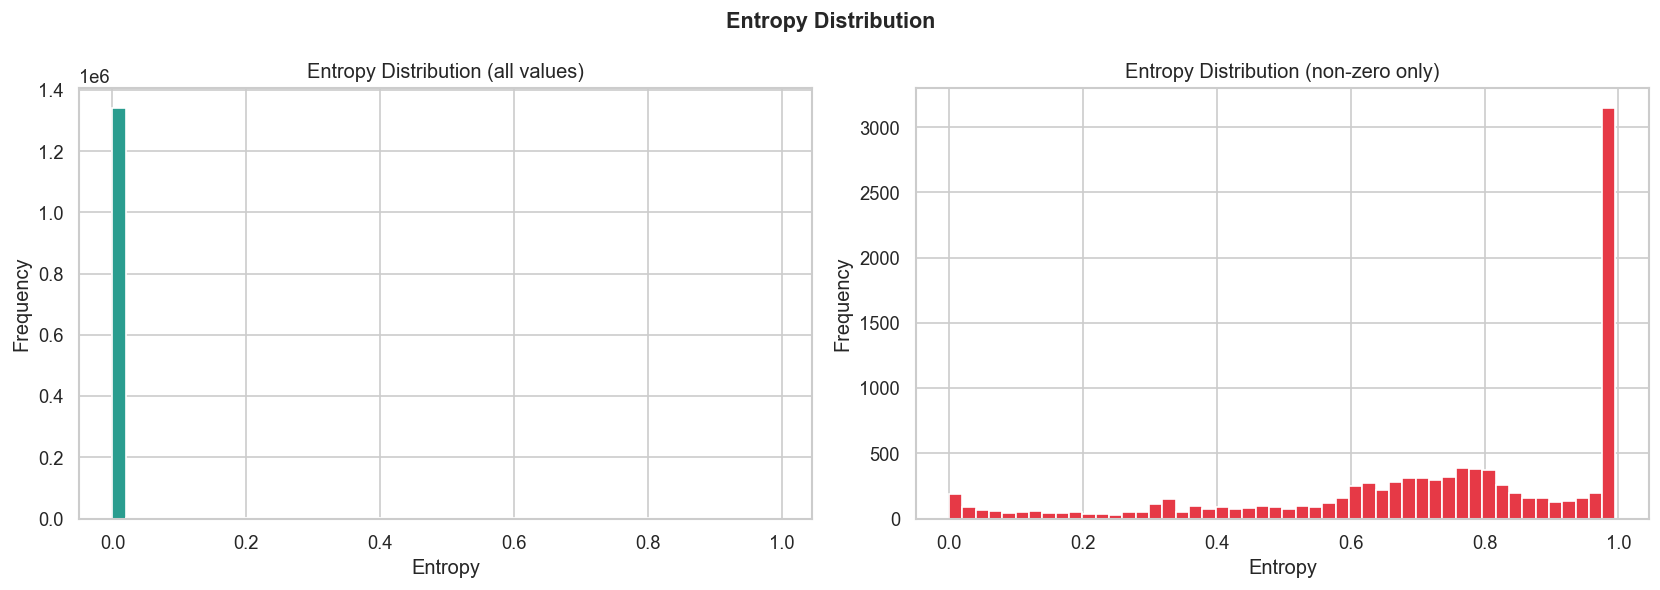

Zero entropy rows    : 1,339,769 (99.2%)
Non-zero entropy rows: 10,231 (0.8%)


In [13]:
# Entropy distribution — full dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — all values including zeros
axes[0].hist(df["entropy"], bins=50, color="#2A9D8F", edgecolor="white")
axes[0].set_title("Entropy Distribution (all values)")
axes[0].set_xlabel("Entropy")
axes[0].set_ylabel("Frequency")

# Right — non-zero only to see real signal
non_zero = df[df["entropy"] > 0]["entropy"]
axes[1].hist(non_zero, bins=50, color="#E63946", edgecolor="white")
axes[1].set_title("Entropy Distribution (non-zero only)")
axes[1].set_xlabel("Entropy")
axes[1].set_ylabel("Frequency")

plt.suptitle("Entropy Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Zero entropy rows    : {(df['entropy'] == 0).sum():,} ({(df['entropy'] == 0).mean()*100:.1f}%)")
print(f"Non-zero entropy rows: {(df['entropy'] > 0).sum():,} ({(df['entropy'] > 0).mean()*100:.1f}%)")

### Observation
- 99.2% of memory writes have zero entropy — these are empty system/background pages
- Only 0.8% (10,231 rows) have meaningful entropy values
- Among non-zero writes, entropy peaks near 1.0 — highly random/encrypted data
- This extreme skewness is why mean entropy per class is so small (0.001 - 0.025)
- The non-zero 0.8% is where the real ransomware signal lives

=== PAGE TYPE DISTRIBUTION ===
page_type
4    1338661
2      11324
1         15
Name: count, dtype: int64

Page type meanings (from dataset):
  1 = unknown
  2 = 4KB page
  4 = dominant page type


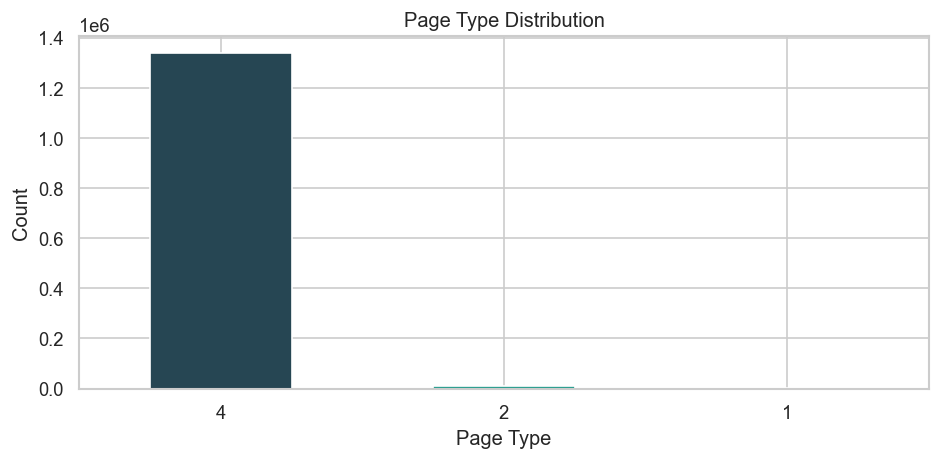

In [14]:
# Page type distribution
print("=== PAGE TYPE DISTRIBUTION ===")
print(df["page_type"].value_counts())
print(f"\nPage type meanings (from dataset):")
print("  1 = unknown")
print("  2 = 4KB page")
print("  4 = dominant page type")

plt.figure(figsize=(8, 4))
df["page_type"].value_counts().plot(kind="bar", color=["#264653","#2A9D8F","#E9C46A"], edgecolor="white")
plt.title("Page Type Distribution")
plt.xlabel("Page Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Page Type Distribution
When any program writes to memory, it writes to different types of memory pages:
- **Type 4** — dominant page type in this dataset
- **Type 2** — 4KB standard memory page
- **Type 1** — unknown/unclassified

### Observation
- Page type 4 dominates — 99.1% of all memory writes
- Page type 2 (4KB pages) — only 0.8%
- Page type 1 (unknown) — negligible (15 rows)
- This feature has very low variance — not useful alone for classification
- Will be more meaningful when combined with other features in Phase 3

## 5. Univariate Analysis

Analyzing one column at a time to understand individual feature behavior.

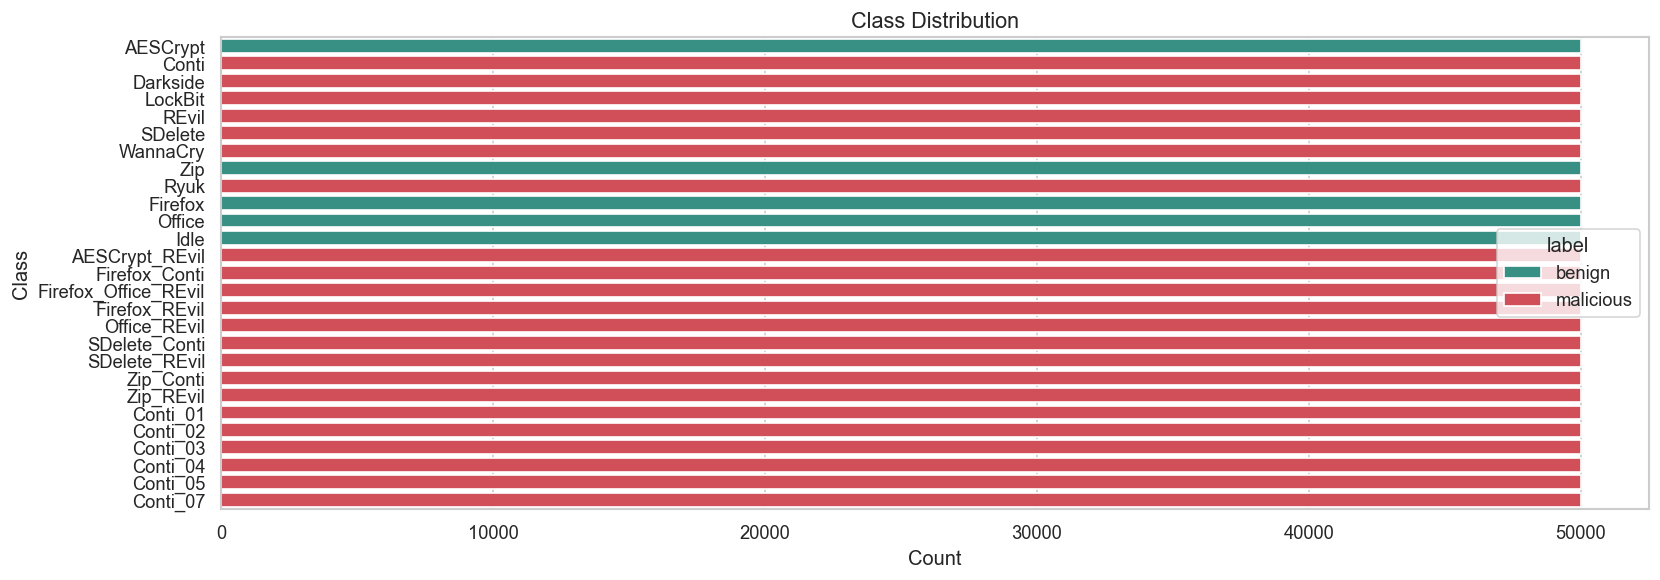

class_name
AESCrypt                50000
Conti                   50000
Darkside                50000
LockBit                 50000
REvil                   50000
SDelete                 50000
WannaCry                50000
Zip                     50000
Ryuk                    50000
Firefox                 50000
Office                  50000
Idle                    50000
AESCrypt_REvil          50000
Firefox_Conti           50000
Firefox_Office_REvil    50000
Firefox_REvil           50000
Office_REvil            50000
SDelete_Conti           50000
SDelete_REvil           50000
Zip_Conti               50000
Zip_REvil               50000
Conti_01                50000
Conti_02                50000
Conti_03                50000
Conti_04                50000
Conti_05                50000
Conti_07                50000
Name: count, dtype: int64


In [15]:
# Class distribution — how many rows per class
plt.figure(figsize=(14, 5))
order = df["class_name"].value_counts().index

sns.countplot(data=df, y="class_name", order=order,
              hue="label",
              palette={"malicious": "#E63946", "benign": "#2A9D8F"})

plt.title("Class Distribution", fontsize=13)
plt.xlabel("Count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

print(df["class_name"].value_counts())

### Observation
- All 27 classes have exactly 50,000 rows — perfectly balanced sample
- 5 pure benign classes: AESCrypt, Zip, Firefox, Office, Idle
- 7 pure malicious classes: WannaCry, LockBit, REvil, Conti, Ryuk, Darkside, SDelete
- 7 Conti variants: Conti_01 to Conti_07
- 9 mix classes: ransomware running alongside benign apps
- Malicious classes dominate — 22 out of 27 classes are malicious

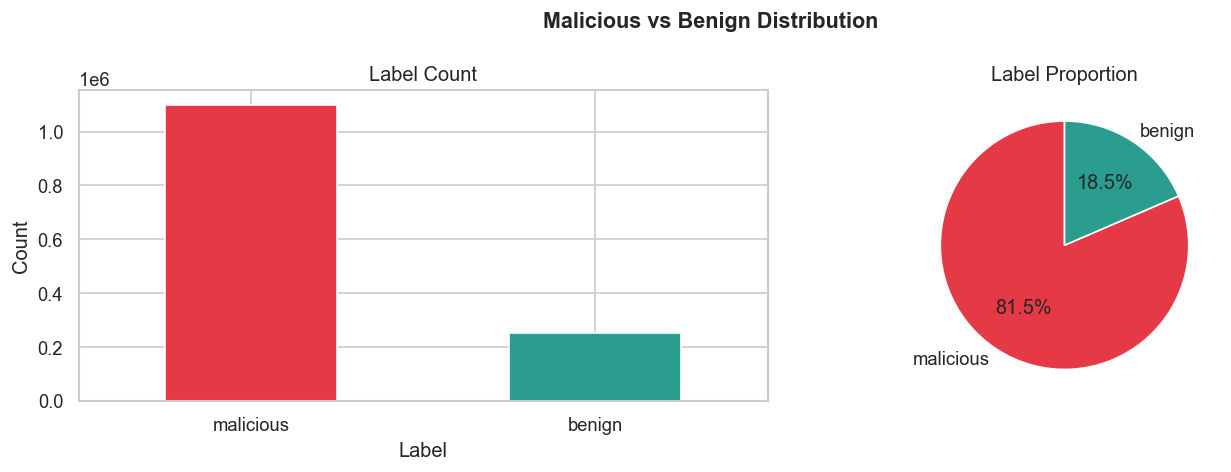

label
malicious    1100000
benign        250000
Name: count, dtype: int64


In [16]:
# Label distribution — malicious vs benign
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df["label"].value_counts().plot(kind="bar", ax=axes[0],
    color=["#E63946", "#2A9D8F"], edgecolor="white")
axes[0].set_title("Label Count")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Pie chart
df["label"].value_counts().plot(kind="pie", ax=axes[1],
    colors=["#E63946", "#2A9D8F"],
    autopct="%1.1f%%", startangle=90)
axes[1].set_title("Label Proportion")
axes[1].set_ylabel("")

plt.suptitle("Malicious vs Benign Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(df["label"].value_counts())

### Observation
- 81.5% malicious vs 18.5% benign — heavily imbalanced dataset
- This imbalance must be handled in Phase 3 before training ML models
- Techniques like class weights or SMOTE will be considered

## 6. Bivariate Analysis

Analyzing relationships between two variables —
how entropy behaves across different classes and labels.

C:\Users\shiva\AppData\Local\Temp\ipykernel_13900\4178153844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["entropy"] > 0], x="label", y="entropy",


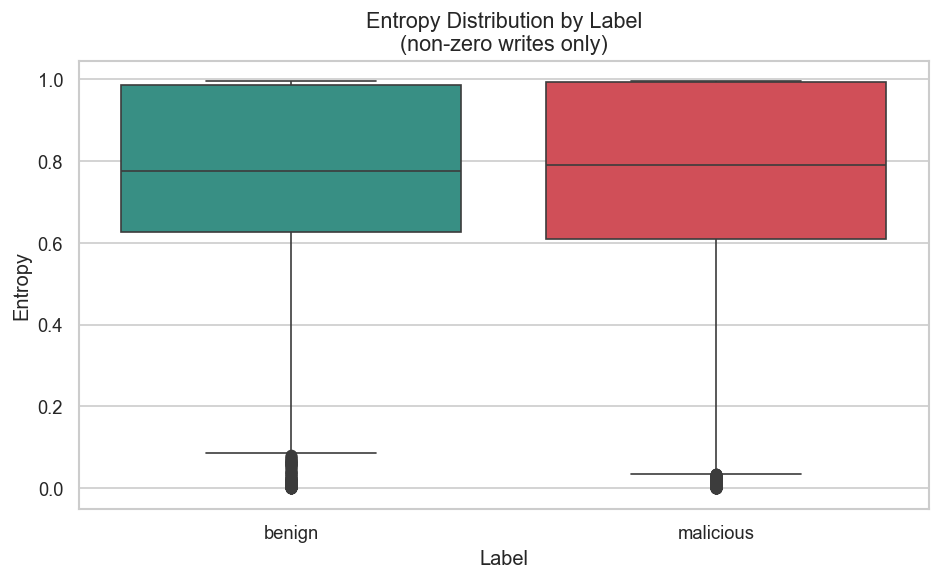

In [17]:
# Entropy by label — boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df["entropy"] > 0], x="label", y="entropy",
            palette={"malicious": "#E63946", "benign": "#2A9D8F"})

plt.title("Entropy Distribution by Label\n(non-zero writes only)", fontsize=13)
plt.xlabel("Label")
plt.ylabel("Entropy")
plt.tight_layout()
plt.show()

### Observation
- Both malicious and benign show similar entropy distributions for non-zero writes
- Median entropy ~0.75-0.80 for both labels
- Both have wide spread (0.0 to 1.0) — large overlap
- This confirms entropy of individual writes cannot classify ransomware alone
- We need behavioral patterns over time windows (Phase 3)

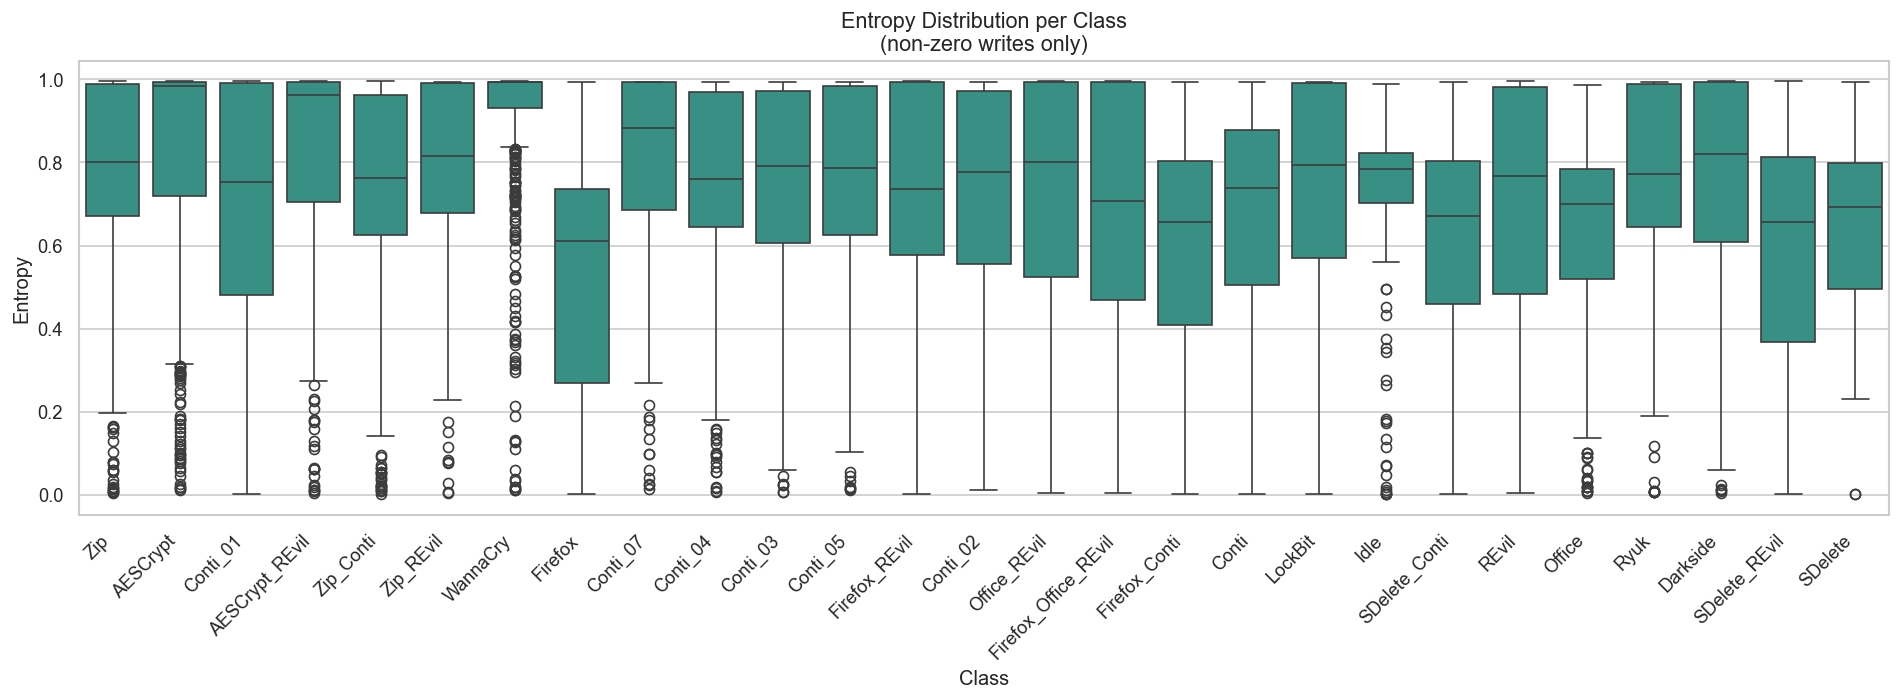

In [19]:
# Entropy per class — boxplot (non-zero only)
plt.figure(figsize=(16, 6))
order = df.groupby("class_name")["entropy"].mean().sort_values(ascending=False).index

sns.boxplot(data=df[df["entropy"] > 0], x="class_name", y="entropy",
            order=order, color="#2A9D8F")

plt.title("Entropy Distribution per Class\n(non-zero writes only)", fontsize=13)
plt.xlabel("Class")
plt.ylabel("Entropy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation
- WannaCry shows many outliers near 0 — mix of encrypted and non-encrypted writes
- SDelete has the lowest overall entropy — overwrites with zeros
- Idle shows outliers scattered — background system activity
- Most classes cluster between 0.6-1.0 for non-zero writes
- AESCrypt and Zip have tighter distributions — consistent encryption/compression behavior

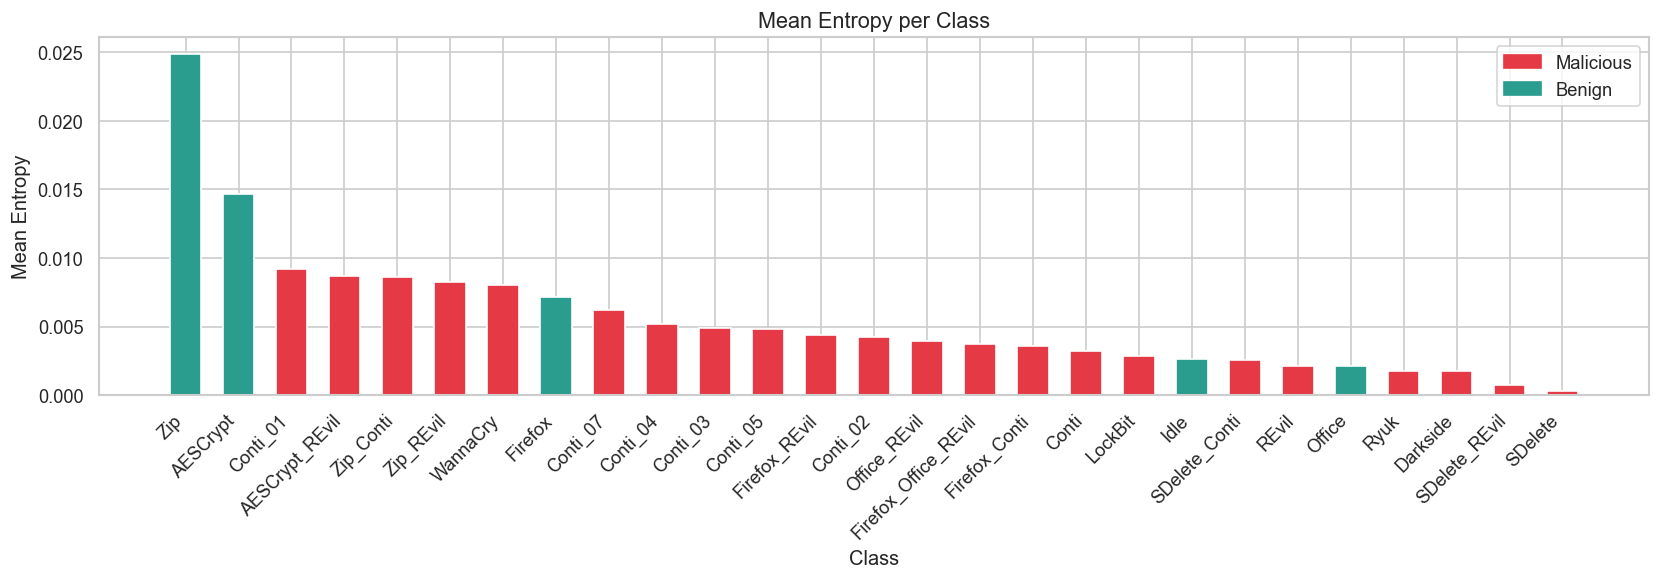

In [20]:
# Mean entropy per class — bar plot
plt.figure(figsize=(14, 5))

ent_mean = df.groupby(["class_name", "label"])["entropy"].mean().reset_index().sort_values("entropy", ascending=False)

colors = ent_mean["label"].map({"malicious": "#E63946", "benign": "#2A9D8F"})

plt.bar(ent_mean["class_name"], ent_mean["entropy"],
        color=colors, edgecolor="white", width=0.6)

plt.title("Mean Entropy per Class", fontsize=13)
plt.xlabel("Class")
plt.ylabel("Mean Entropy")
plt.xticks(rotation=45, ha="right")

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color="#E63946", label="Malicious"),
                    Patch(color="#2A9D8F", label="Benign")])
plt.tight_layout()
plt.show()

### Observation
- Zip and AESCrypt (benign) have highest mean entropy — legitimate compression/encryption
- Conti_01, AESCrypt_REvil, Zip_Conti (malicious) follow next
- WannaCry is highest among pure ransomware classes
- SDelete nearly zero — destroys data by overwriting with zeros
- Benign mean entropy is actually higher than most malicious classes
- This is the core challenge — entropy alone cannot distinguish ransomware from benign

C:\Users\shiva\AppData\Local\Temp\ipykernel_13900\767042088.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["entropy"] > 0], x="split", y="entropy",


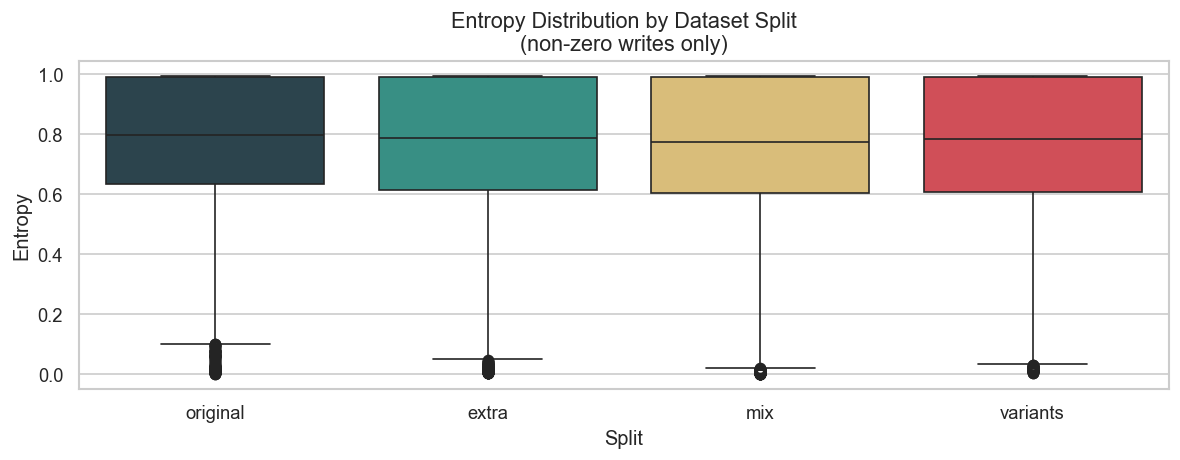

Mean entropy per split:
split
extra       0.00702
mix         0.00495
original    0.00550
variants    0.00576
Name: entropy, dtype: float32


In [21]:
# Entropy by dataset split
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[df["entropy"] > 0], x="split", y="entropy",
            palette=["#264653", "#2A9D8F", "#E9C46A", "#E63946"])

plt.title("Entropy Distribution by Dataset Split\n(non-zero writes only)", fontsize=13)
plt.xlabel("Split")
plt.ylabel("Entropy")
plt.tight_layout()
plt.show()

print("Mean entropy per split:")
print(df.groupby("split")["entropy"].mean().round(5))

### Observation
- All 4 splits show very similar entropy distributions
- Median entropy ~0.75-0.80 across all splits
- Extra split has slightly higher mean (0.007) — different hardware config
- Mix split has slightly lower mean (0.005) — ransomware competing with benign apps
- Overall consistent — model trained on original will generalize across hardware

## 7. Outlier Detection

Identifying extreme or unusual values in the data.

In [22]:
# Outlier detection on entropy using IQR method
Q1 = df["entropy"].quantile(0.25)
Q3 = df["entropy"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["entropy"] < lower) | (df["entropy"] > upper)]

print("=== OUTLIER DETECTION (IQR Method) ===")
print(f"Q1          : {Q1:.4f}")
print(f"Q3          : {Q3:.4f}")
print(f"IQR         : {IQR:.4f}")
print(f"Lower bound : {lower:.4f}")
print(f"Upper bound : {upper:.4f}")
print(f"\nOutlier rows : {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
print(f"\nOutliers per class:")
print(outliers["class_name"].value_counts())

=== OUTLIER DETECTION (IQR Method) ===
Q1          : -0.0000
Q3          : 0.0000
IQR         : 0.0000
Lower bound : -0.0000
Upper bound : 0.0000

Outlier rows : 10,231 (0.8%)

Outliers per class:
class_name
Zip                     1573
AESCrypt                 885
Firefox                  684
Conti_01                 665
Zip_Conti                588
AESCrypt_REvil           534
Zip_REvil                514
WannaCry                 449
Conti_07                 385
Conti_04                 353
Conti_03                 332
Conti_05                 322
Firefox_REvil            307
Firefox_Conti            298
Conti_02                 293
Firefox_Office_REvil     278
Office_REvil             276
Conti                    242
SDelete_Conti            211
LockBit                  198
Idle                     188
Office                   174
REvil                    155
Ryuk                     122
Darkside                 117
SDelete_REvil             62
SDelete                   26
Name: cou

### Observation
- IQR method flags 10,231 rows (0.8%) as outliers
- But these are NOT real outliers — they are the actual encryption events
- Because 99.2% of entropy is zero, IQR treats any non-zero value as extreme
- The "outliers" are exactly what we WANT to detect — high entropy writes
- Zip (1573) and AESCrypt (885) have most — confirms legitimate encryption activity
- SDelete has only 26 — almost all zero entropy, consistent with zero-overwrite behavior
- Standard outlier removal would DESTROY our signal — we keep all rows

## 8. Correlation Analysis

Understanding relationships between numerical features.

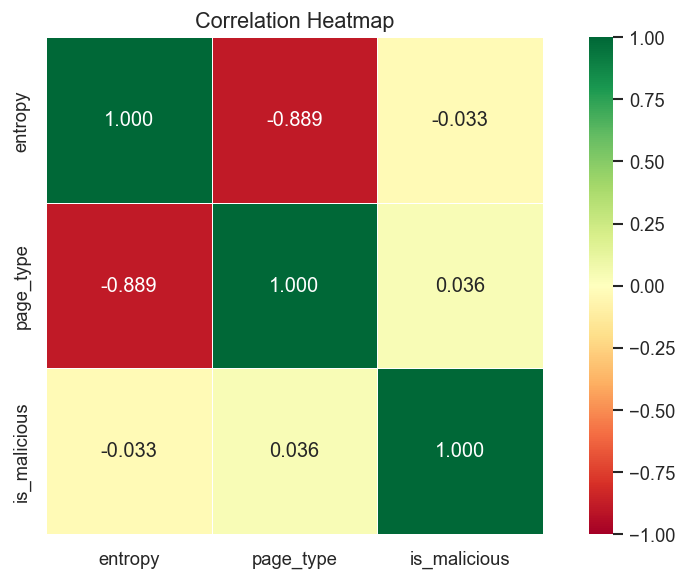

               entropy  page_type  is_malicious
entropy       1.000000  -0.888504     -0.033097
page_type    -0.888504   1.000000      0.036125
is_malicious -0.033097   0.036125      1.000000


In [23]:
# Correlation heatmap — numerical columns only
plt.figure(figsize=(8, 5))

corr = df[["entropy", "page_type", "is_malicious"]].corr()

sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()

print(corr)

### Observation
- **entropy vs page_type : -0.889** — strong negative correlation
  - Higher entropy writes happen on lower page_type numbers (type 2 = 4KB pages)
  - Makes sense — actual file encryption happens on small 4KB memory pages
- **entropy vs is_malicious : -0.033** — almost zero correlation
  - Confirms entropy alone cannot predict malicious behavior
- **page_type vs is_malicious : 0.036** — almost zero correlation
  - Page type alone also cannot predict malicious behavior
- Both features individually are weak predictors
- This strongly motivates the 18-feature approach from the paper —
  combining entropy, page counts, and variance across all access types

## 9. Key Findings & Insights

Summary of everything discovered in EDA.

In [24]:
print("=" * 55)
print("  PHASE 2 EDA — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
DATASET:
  Rows          : {len(df):,}
  Classes       : {df['class_name'].nunique()}
  Malicious     : {(df['label']=='malicious').sum():,} (81.5%)
  Benign        : {(df['label']=='benign').sum():,} (18.5%)

DATA QUALITY:
  Missing values : 0
  Negative entropy fixed : Yes
  Mix class labels fixed : Yes

ENTROPY FINDINGS:
  99.2% of writes have zero entropy
  Only 0.8% are meaningful non-zero writes
  Zip highest entropy  : 0.0248
  SDelete lowest       : 0.0003
  Benign mean > Malicious mean

KEY INSIGHTS:
  1. Entropy alone CANNOT classify ransomware
  2. SDelete destroys data with zeros — low entropy
  3. AESCrypt/Zip (benign) mimic ransomware entropy
  4. Hardware differences negligible across splits
  5. Dataset is imbalanced — needs handling in Phase 3
  6. Individual features weakly correlated with label
  7. Need 18-feature behavioral approach from the paper

NEXT → Phase 3: Feature Engineering
""")

  PHASE 2 EDA — KEY FINDINGS SUMMARY

DATASET:
  Rows          : 1,350,000
  Classes       : 27
  Malicious     : 1,100,000 (81.5%)
  Benign        : 250,000 (18.5%)

DATA QUALITY:
  Missing values : 0
  Negative entropy fixed : Yes
  Mix class labels fixed : Yes

ENTROPY FINDINGS:
  99.2% of writes have zero entropy
  Only 0.8% are meaningful non-zero writes
  Zip highest entropy  : 0.0248
  SDelete lowest       : 0.0003
  Benign mean > Malicious mean

KEY INSIGHTS:
  1. Entropy alone CANNOT classify ransomware
  2. SDelete destroys data with zeros — low entropy
  3. AESCrypt/Zip (benign) mimic ransomware entropy
  4. Hardware differences negligible across splits
  5. Dataset is imbalanced — needs handling in Phase 3
  6. Individual features weakly correlated with label
  7. Need 18-feature behavioral approach from the paper

NEXT → Phase 3: Feature Engineering



In [25]:
# Save cleaned sample for Phase 3
# This avoids reloading and re-cleaning data every time
df.to_parquet(os.path.join(PROCESSED, "eda_cleaned_sample.parquet"), index=False)
print(f"Saved! Shape: {df.shape}")
print(f"Location: {PROCESSED}\\eda_cleaned_sample.parquet")

Saved! Shape: (1350000, 7)
Location: C:\Users\Shiva\Downloads\RANSMAP_PROJECT\DATA\processed\eda_cleaned_sample.parquet


## Conclusion

**What we covered in Phase 2 EDA:**

1. Understanding the dataset — shape, dtypes, columns
2. Data cleaning — nulls, duplicates, negative entropy, label fixes
3. Descriptive statistics — mean, median, std per class
4. Distributions — entropy histogram, page type
5. Univariate analysis — class distribution, label distribution
6. Bivariate analysis — entropy vs label, entropy vs class, entropy vs split
7. Outlier detection — IQR method, found signal not noise
8. Correlation analysis — heatmap
9. Key findings summary

**Data Quality Summary:**

| Check | Result |
|---|---|
| Missing values | 0 — nothing to fix |
| Duplicates | Expected — kept all (real events) |
| Negative entropy | Fixed — clipped to 0 |
| Mix class labels | Fixed — unknown → malicious |
| Data types | Correct — float32, int8, object |
| Outliers | Kept — they are the actual signal |

Phase 2 EDA revealed that individual memory write features (entropy, page_type) 
have very weak correlation with malicious behavior on their own.

The key challenge is that benign apps like AESCrypt and Zip produce 
similar entropy patterns to ransomware.

This motivates the paper's approach — instead of individual events, 
we need **behavioral patterns over time windows** combining:
- Shannon entropy (H)
- Page access counts (C_4KB, C_2MB, C_MMIO)
- Address variance (V)
across all 4 access types → **18 features total**

**Next → Phase 3: Feature Engineering**